In [1]:
!pip install beautifulsoup4
!pip install lxml
!pip install nltk
!pip install wordcloud

In [2]:
from bs4 import BeautifulSoup
from tqdm import tqdm
import os
import nltk
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Marlow\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
def clean_speech(speech):
    text_classes = ['J_1', 'J', 'O']
    excepts = 0
    clean_ps = []
    paragraphs = speech.find_all('p')
    for x in range(len(paragraphs) - 1):
        if paragraphs[x].attrs is not None:
            try:
                if paragraphs[x]['klasse'] in text_classes:
                    clean_ps.append(paragraphs[x].get_text())
                    # print(f"{paragraphs[x].get_text()} \n")
            except:
                excepts += 1

    speaker = speech.find_next('p', {'klasse': 'redner'})
    party = ''
    if speaker.find('fraktion') is not None:
        party = speaker.find('fraktion').get_text()

    role = ''
    if speaker.find('rolle') is not None:
        role = speaker.find('rolle_lang').get_text()

    clean_rede = {
        'speaker': speaker,
        'party': party,
        'role': role,
        'speech': ' '.join(clean_ps)
    }
    # if excepts > 0:
        # print(f"Ausnahmen: {excepts}")
    return clean_rede, excepts


In [4]:
# read and clean stopwords
dir_stop = 'SnowballStopwordsGerman.txt'
sep = '|'
german_stopwords = []
with open("SnowballStopwordsGerman.txt", encoding='windows-1252') as file_in:
    stopwords = [line.rstrip('\n') for line in file_in]
    for s in stopwords:
        split = s.split(sep)[0]
        if split != " " and split != "," and split != "":
            german_stopwords.append(s.split(sep)[0].strip())

In [5]:
print(german_stopwords)

['aber', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also', 'am', 'an', 'ander', 'andere', 'anderem', 'anderen', 'anderer', 'anderes', 'anderm', 'andern', 'anderr', 'anders', 'auch', 'auf', 'aus', 'bei', 'bin', 'bis', 'bist', 'da', 'damit', 'dann', 'der', 'den', 'des', 'dem', 'die', 'das', 'daß', 'derselbe', 'derselben', 'denselben', 'desselben', 'demselben', 'dieselbe', 'dieselben', 'dasselbe', 'dazu', 'dein', 'deine', 'deinem', 'deinen', 'deiner', 'deines', 'denn', 'derer', 'dessen', 'dich', 'dir', 'du', 'dies', 'diese', 'diesem', 'diesen', 'dieser', 'dieses', 'doch', 'dort', 'durch', 'ein', 'eine', 'einem', 'einen', 'einer', 'eines', 'einig', 'einige', 'einigem', 'einigen', 'einiger', 'einiges', 'einmal', 'er', 'ihn', 'ihm', 'es', 'etwas', 'euer', 'eure', 'eurem', 'euren', 'eurer', 'eures', 'für', 'gegen', 'gewesen', 'hab', 'habe', 'haben', 'hat', 'hatte', 'hatten', 'hier', 'hin', 'hinter', 'ich', 'mich', 'mir', 'ihr', 'ihre', 'ihrem', 'ihren', 'ihrer', 'ihres', 'euch', 'im'

In [6]:
# create positive word rating (check ratings)
positive_words = []
positive_word_rating = []
with open('SentiWS_v1.8c_Positive.txt','r', encoding='UTF-8') as file:
    positive_words = file.readlines()
    for s in positive_words:   #needs to be changed
        words = []
        first_half = s.split('|')[0]
        second_half = s.split('|')[1]
        words.append(first_half)
        #print(words)
        second_half_splitted = second_half.split()
        rating = second_half_splitted[1]
        if len(second_half_splitted) > 2:  #if there are further words
            further_words = second_half_splitted[2]
            rating = second_half_splitted[1]
            if(len(further_words) > 1): #more than one further word
                #print(further_words)
                #rating = second_half_splitted[1]
                splitted_again = further_words.split(',')
                for word in splitted_again:
                    words.append(word)
                #print(words)
            else:
                rating = second_half_splitted[1]
                words.append(further_words)



        for word in words:
            word_rating = {
                'word': word,
                'rating': float(rating)

            }
            positive_word_rating.append(word_rating)


In [7]:
negative_words = []
negative_word_rating = []
with open('SentiWS_v1.8c_Negative.txt','r', encoding='UTF-8') as file:
    negative_words = file.readlines()
    for s in negative_words:   #needs to be changed
        words = []
        first_half = s.split('|')[0]
        second_half = s.split('|')[1]
        words.append(first_half)
        #print(words)
        second_half_splitted = second_half.split()
        rating = second_half_splitted[1]
        if len(second_half_splitted) > 2:  #if there are further words
            further_words = second_half_splitted[2]
            rating = second_half_splitted[1]
            if(len(further_words) > 1): #more than one further word
                #print(further_words)
                #rating = second_half_splitted[1]
                splitted_again = further_words.split(',')
                for word in splitted_again:
                    words.append(word)
                #print(words)
            else:
                rating = second_half_splitted[1]
                words.append(further_words)



        for word in words:
            word_rating = {
                'word': word,
                'rating': float(rating)

            }
            negative_word_rating.append(word_rating)


In [8]:
word_rating_combined = positive_word_rating + negative_word_rating

In [9]:
def score_speech_pos(speech):
    sum = 0.0
    for token in speech:
        item = next((item for item in positive_word_rating if item["word"].casefold() == token.casefold()), None)
        if item is not None:
            sum += item['rating']
    return sum

def score_speech_neg(speech):
    sum = 0.0
    for token in speech:
        item = next((item for item in negative_word_rating if item["word"].casefold() == token.casefold()), None)
        if item is not None:
            sum += item['rating']
    return sum

def score_speech(speech):
    sum = 0.0
    for token in speech:
        item = next((item for item in word_rating_combined if item["word"].casefold() == token.casefold()), None)
        if item is not None:
            sum += item['rating']
    return sum


In [10]:
protocols = []
parties = []
dir = 'data_wp20'

files = os.listdir(dir)
files.sort()
# print(files) #for debugging
num_exceptions = 0
exception_list = []
for file in tqdm(files):
    f = os.path.join(dir, file)
    with open(f, 'r',encoding='utf-8') as file:
        data = file.read()
        data = BeautifulSoup(data, "xml")
        speeches = data.find_all('rede')
        speeches_clean = []
        tokenized_speech = []
        # print(file) #for debugging
        for x in speeches:
            # print(x['id']) #for debugging
            cleaned_speech, exceptions = clean_speech(x)
            if exceptions > 0:
                num_exceptions += exceptions
                exception_list.append({'num_of_errors':exceptions, 'speech_id':x['id'], 'file_name':file.name})
                # print(f"Datei: {file.name}") #for debugging
                # print(f"{exceptions} Fehler in Rede ID: {x['id']}") #for debugging
                # print(clean_speech(x)) #for debugging
            speeches_clean.append(cleaned_speech)

        protocol = {
            'session': data.find('sitzungsnr'),
            'speeches': speeches_clean,
            'speeker': data.rednerliste.find_all('redner'),
            'data': data,
        }
        protocols.append(protocol)
print(f"{num_exceptions} Fehler in den Reden: {len(exception_list)}")

100%|██████████| 139/139 [00:48<00:00,  2.85it/s]

0 Fehler in den Reden: 0


In [11]:
exception_list

[]

In [12]:
# protocols[120]["speeches"][11]["speaker"].find("nachname").getText()
# next(item for item in protocols[120]["speeches"] if item["speaker"].find("nachname").getText() == 'Henneberger')

In [13]:
# Number of protocols and speeches
print(len(protocols))
cnt = 0
for x in protocols:
    cnt += len(x['speeches'])
print(cnt)

139
17224


In [14]:
parties = []
speeches = []
speaker = []
speakerids = []

for p in protocols:
    for s in p['speeches']:
        # print(s) #for debugging
        # print('') #for debugging
        speeches.append(s['speech'])
        clean_party_string = " ".join(s['party'].split())
        name = ' '.join([s['speaker'].find('vorname').get_text(), s['speaker'].find('nachname').get_text()])
        name = ' '.join(name.split())
        included = False
        for f in parties:
            if f['party'] == clean_party_string:
                f['speeches'].append(s['speech'])
                if name not in f['speaker']:
                    f['speaker'].append(name)
                included = True
        if not included:
            party = {'party' : clean_party_string,
                     'speeches' : [s['speech']],
                     'speaker' : [name]
                     }
            parties.append(party)

        if s['speaker'].find('redner')['id'] not in speakerids:
            name = ' '.join([s['speaker'].find('vorname').get_text(), s['speaker'].find('nachname').get_text()])
            name = ' '.join(name.split())
            speaker.append(name)
            speakerids.append(s['speaker'].find('redner')['id'])

In [15]:
for f in parties:
    print(f"Party: {f['party']}")
    print(f"Number of speeches: {len(f['speeches'])}")
    print("")

Party: SPD
Number of speeches: 3402

Party: CDU/CSU
Number of speeches: 3717

Party: BÜNDNIS 90/DIE GRÜNEN
Number of speeches: 2286

Party: AfD
Number of speeches: 2015

Party: FDP
Number of speeches: 1871

Party: DIE LINKE
Number of speeches: 1451

Party: 
Number of speeches: 2243

Party: Fraktionslos
Number of speeches: 183

Party: SPDCDU/CSU
Number of speeches: 6

Party: fraktionslos
Number of speeches: 50



In [16]:
for redner in parties[9]['speaker']:
    if redner not in parties[7]['speaker']:
        parties[7]['speaker'].append(redner)
for reden in parties[9]['speeches']:
    parties[7]['speeches'].append(reden)

In [17]:
len(parties[7]['speeches'])

233

In [18]:
redner = []
for p in protocols:
    for s in p['speeches']:
        name = ' '.join([s['speaker'].find('vorname').get_text(), s['speaker'].find('nachname').get_text()])
        name = ' '.join(name.split())
        included = False
        for r in redner:
            if r['name'] == name:
                r['reden'].append(s['speech'])
                included = True
        if not included:
            redner.append({'name': name, 'redner': s['speaker'], 'reden': [s['speech']]})

In [19]:
len(speaker)

771

In [20]:
len(redner)

775

In [21]:
def copy_speeches(target_dict, source_dict, name_to_find):
    temp = next(item for item in source_dict if item['name'] == name_to_find)

    missing_speeches = set(temp['reden']) - set(target_dict['speeches'])

    target_dict['speeches'].extend(list(missing_speeches))


In [22]:
only_in_no_tag = []
multi_speaker = []
for name in parties[6]['speaker']:
    for x in range(len(parties)):
        if name in parties[x]['speaker']:
            if x != 6:
                print(f"Name: {name}, X = {x}")
                multi_speaker.append({'name': name, 'protocol_id': x})
            else:
                only_in_no_tag.append(name)

print(f"Anzahl multispeaker: ", len(multi_speaker))
for s in [d['name'] for d in multi_speaker]:
    only_in_no_tag.remove(s)

print(f"Anzahl nicht multispeaker: ", len(only_in_no_tag))
only_in_no_tag

Name: Olaf Scholz, X = 0
Name: Robert Habeck, X = 2
Name: Marco Buschmann, X = 4
Name: Karl Lauterbach, X = 0
Name: Steffi Lemke, X = 2
Name: Bettina Stark-Watzinger, X = 4
Name: Kerstin Griese, X = 0
Name: Sabine Dittmar, X = 0
Name: Benjamin Strasser, X = 4
Name: Pascal Kober, X = 4
Name: Michael Kellner, X = 2
Name: Cansel Kiziltepe, X = 0
Name: Franziska Brantner, X = 2
Name: Ekin Deligöz, X = 2
Name: Sven Lehmann, X = 2
Name: Lisa Paus, X = 2
Name: Oliver Krischer, X = 2
Name: Katja Hessel, X = 4
Name: Johann Saathoff, X = 0
Name: Mario Brandenburg, X = 4
Name: Christian Kühn, X = 2
Name: Luise Amtsberg, X = 2
Name: Dieter Janecek, X = 2
Name: Jens Brandenburg, X = 4
Name: Katja Kipping, X = 5
Name: Anna Christmann, X = 2
Name: Ophelia Nick, X = 2
Name: Claudia Müller, X = 2
Name: Elisabeth Kaiser, X = 0
Name: Michael Theurer, X = 4
Name: Edgar Franke, X = 0
Anzahl multispeaker:  31
Anzahl nicht multispeaker:  52


['Heiko Maas',
 'Joachim Stamp',
 'Sarah Ryglewski',
 'Christian Lindner',
 'Nancy Faeser',
 'Annalena Baerbock',
 'Hubertus Heil',
 'Christine Lambrecht',
 'Cem Özdemir',
 'Anne Spiegel',
 'Volker Wissing',
 'Svenja Schulze',
 'Klara Geywitz',
 'Wolfgang Schmidt',
 'Carsten Schneider',
 'Reem Alabali-Radovan',
 'Anna Lührmann',
 'Siemtje Möller',
 'Dietmar Woidke',
 'Andreas Bovenschulte',
 'Claudia Roth',
 'Oliver Luksic',
 'Andreas Pinkwart',
 'Eva Högl',
 'Sven Schulze',
 'Katja Keul',
 'Anette Kramme',
 'Florian Toncar',
 'Tobias Lindner',
 'Thomas Hitschler',
 'Peter Beuth',
 'Reiner Haseloff',
 'Klaus Holetschek',
 'Bettina Hoffmann',
 'Daniela Kluckert',
 'Mahmut Özdemir',
 'Jörg Steinbach',
 'Boris Pistorius',
 'Anke Rehlinger',
 'Dirk-UlrichLena Mende Kreck',
 'Bettina Jarasch',
 'Roman Poseck',
 'Sören Bartol',
 'Rita Schwarzelühr-Sutter',
 'Thomas Schmidt',
 'Kristina Sinemus',
 'Bärbel Kofler',
 'Judith Gerlach',
 'Niels Annen',
 'Daniela Behrens',
 'Armin Schuster',
 'Bur

In [23]:
multi_speaker.extend([{'name': 'Heiko Maas', 'protocol_id': 0},
                      {'name': 'Joachim Stamp', 'protocol_id': 4},
                      {'name': 'Sarah Ryglewski', 'protocol_id': 0},
                      {'name': 'Christian Lindner', 'protocol_id': 4},
                      {'name': 'Nancy Faeser', 'protocol_id': 0},
                      {'name': 'Annalena Baerbock', 'protocol_id': 2},
                      {'name': 'Hubertus Heil', 'protocol_id': 0},
                      {'name': 'Christine Lambrecht', 'protocol_id': 0},
                      {'name': 'Cem Özdemir', 'protocol_id': 2},
                      {'name': 'Anne Spiegel', 'protocol_id': 2},
                      {'name': 'Volker Wissing', 'protocol_id': 4},
                      {'name': 'Svenja Schulze', 'protocol_id': 0},
                      {'name': 'Klara Geywitz', 'protocol_id': 0},
                      {'name': 'Wolfgang Schmidt', 'protocol_id': 0},
                      {'name': 'Carsten Schneider', 'protocol_id': 0},
                      {'name': 'Reem Alabali-Radovan', 'protocol_id': 0},
                      {'name': 'Anna Lührmann', 'protocol_id': 2},
                      {'name': 'Siemtje Möller', 'protocol_id': 0},
                      {'name': 'Dietmar Woidke', 'protocol_id': 0},
                      {'name': 'Andreas Bovenschulte', 'protocol_id': 0},
                      {'name': 'Claudia Roth', 'protocol_id': 2},
                      {'name': 'Oliver Luksic', 'protocol_id': 4},
                      {'name': 'Andreas Pinkwart', 'protocol_id': 4},
                      {'name': 'Eva Högl', 'protocol_id': 0},
                      {'name': 'Sven Schulze', 'protocol_id': 1},
                      {'name': 'Katja Keul', 'protocol_id': 2},
                      {'name': 'Anette Kramme', 'protocol_id': 0},
                      {'name': 'Florian Toncar', 'protocol_id': 4},
                      {'name': 'Tobias Lindner', 'protocol_id': 2},
                      {'name': 'Thomas Hitschler', 'protocol_id': 0},
                      {'name': 'Peter Beuth', 'protocol_id': 1},
                      {'name': 'Reiner Haseloff', 'protocol_id': 1},
                      {'name': 'Klaus Holetschek', 'protocol_id': 1},
                      {'name': 'Bettina Hoffmann', 'protocol_id': 2},
                      {'name': 'Daniela Kluckert', 'protocol_id': 4},
                      {'name': 'Mahmut Özdemir', 'protocol_id': 0},
                      {'name': 'Jörg Steinbach', 'protocol_id': 0},
                      {'name': 'Boris Pistorius', 'protocol_id': 0},
                      {'name': 'Anke Rehlinger', 'protocol_id': 0},
                      {'name': 'Bettina Jarasch', 'protocol_id': 2},
                      {'name': 'Roman Poseck', 'protocol_id': 1},
                      {'name': 'Sören Bartol', 'protocol_id': 0},
                      {'name': 'Rita Schwarzelühr-Sutter', 'protocol_id': 0},
                      {'name': 'Thomas Schmidt', 'protocol_id': 1},
                      {'name': 'Kristina Sinemus', 'protocol_id': 4},
                      {'name': 'Bärbel Kofler', 'protocol_id': 0},
                      {'name': 'Judith Gerlach', 'protocol_id': 1},
                      {'name': 'Niels Annen', 'protocol_id': 0},
                      {'name': 'Daniela Behrens', 'protocol_id': 0},
                      {'name': 'Armin Schuster', 'protocol_id': 1},
                      {'name': 'Burkhard Blienert', 'protocol_id': 0}])

In [24]:
len(multi_speaker)

82

In [25]:
for d in multi_speaker:
    copy_speeches(parties[d['protocol_id']], redner, d['name'])

In [26]:
for f in parties:
    print(f"Party: {f['party']}")
    print(f"Number of speeches: {len(f['speeches'])}")
    print("")

Party: SPD
Number of speeches: 4483

Party: CDU/CSU
Number of speeches: 3733

Party: BÜNDNIS 90/DIE GRÜNEN
Number of speeches: 2903

Party: AfD
Number of speeches: 2015

Party: FDP
Number of speeches: 2373

Party: DIE LINKE
Number of speeches: 1452

Party: 
Number of speeches: 2243

Party: Fraktionslos
Number of speeches: 233

Party: SPDCDU/CSU
Number of speeches: 6

Party: fraktionslos
Number of speeches: 50



In [27]:
### create a list with objects consisting of speeches with the corresponding speaker and party and protocol number
ger_stopwords_casefold = []
for x in german_stopwords:
    ger_stopwords_casefold.append(x.casefold())

def create_tokenized_speeches(speeches, party):
    tokenized_speech = []
    for speech in tqdm(speeches):
        # print(speech)  #for debugging
        clean_speech = speech.split()
        filtered_speech = ' '.join([word for word in clean_speech if word.casefold() not in ger_stopwords_casefold])
        clean_party = party


        combined_tokenized_speech_party = {
            'party': clean_party,
            'tokenized_speech': nltk.word_tokenize(filtered_speech)
        }

        tokenized_speech.append(combined_tokenized_speech_party)
    return tokenized_speech


In [28]:
def create_rating_df(tokenized_speeches):
    speech_rating = []
    print(f"Party of 1st speech: {tokenized_speeches[0]['party']}")
    for speech in tqdm(tokenized_speeches):
        rating = score_speech(speech['tokenized_speech'])
        rating_of_speech_dict = {
            'party': speech['party'],
            'rating': rating
        }
        speech_rating.append(rating_of_speech_dict)

    print(len(speech_rating))
    return pd.DataFrame(speech_rating)

In [29]:
speeches_spd = create_tokenized_speeches(parties[0]['speeches'], parties[0]['party'])
speeches_cdu_csu = create_tokenized_speeches(parties[1]['speeches'], parties[1]['party'])
speeches_b90 = create_tokenized_speeches(parties[2]['speeches'], parties[2]['party'])
speeches_afd = create_tokenized_speeches(parties[3]['speeches'], parties[3]['party'])
speeches_fdp = create_tokenized_speeches(parties[4]['speeches'], parties[4]['party'])
speeches_linke = create_tokenized_speeches(parties[5]['speeches'], parties[5]['party'])
# speeches_no_tag = create_tokenized_speeches(parties[6]['speeches'], parties[6]['party'])
speeches_fraktionslos = create_tokenized_speeches(parties[7]['speeches'], parties[7]['party'])
# speeches_SPDCDU_CSU = create_tokenized_speeches(parties[8]['speeches'], parties[8]['party'])
# speeches_fraktionslos2 = create_tokenized_speeches(parties[9]['speeches'], parties[9]['party'])

100%|██████████| 233/233 [00:00<00:00, 459.89it/s]


In [30]:
all_speeches = [speeches_spd, speeches_cdu_csu, speeches_b90, speeches_afd, speeches_fdp, speeches_linke, speeches_fraktionslos] #speeches_no_tag,

In [31]:
df_list = []
cnt = 0
for speeches in all_speeches:
    temp_df = create_rating_df(speeches) #about 2 sec per speech
    temp_df.to_csv("ratings"+str(cnt)+".csv")
    df_list.append(temp_df)
    cnt += 1


  0%|          | 0/4483 [00:00<?, ?it/s]

Party of 1st speech: SPD


  0%|          | 0/3733 [00:00<?, ?it/s]

4483
Party of 1st speech: CDU/CSU


  0%|          | 0/2903 [00:00<?, ?it/s]

...

2373
Party of 1st speech: DIE LINKE


  0%|          | 0/233 [00:00<?, ?it/s]

1452
Party of 1st speech: Fraktionslos


100%|██████████| 233/233 [03:44<00:00,  1.04it/s]

233


In [32]:
cnt = 0
for df in df_list:
    df.to_csv("rating_csvs/ratings"+str(cnt)+".csv")
    cnt += 1

# Visualisierung

In [31]:
dfs = []
for file in os.listdir("rating_csvs"):
    dfs.append(pd.read_csv(os.path.join("rating_csvs", file), index_col=0))

dfs

[     party  rating
 0      SPD  1.2089
 1      SPD  5.0524
 2      SPD  0.0837
 3      SPD -1.3851
 4      SPD  0.9943
 ...    ...     ...
 4478   SPD  0.7294
 4479   SPD  0.9693
 4480   SPD  0.6089
 4481   SPD  1.7142
 4482   SPD -0.0097
 
 [4483 rows x 2 columns],
         party  rating
 0     CDU/CSU  2.4015
 1     CDU/CSU -1.8011
 2     CDU/CSU -1.3608
 3     CDU/CSU -3.8505
 4     CDU/CSU -2.7957
 ...       ...     ...
 3728  CDU/CSU  2.2934
 3729  CDU/CSU  3.2675
 3730  CDU/CSU  3.0841
 3731  CDU/CSU  1.6330
 3732  CDU/CSU  1.9803
 
 [3733 rows x 2 columns],
                       party  rating
 0     BÜNDNIS 90/DIE GRÜNEN  1.5477
 1     BÜNDNIS 90/DIE GRÜNEN  2.9660
 2     BÜNDNIS 90/DIE GRÜNEN  0.2890
 3     BÜNDNIS 90/DIE GRÜNEN -3.7505
 4     BÜNDNIS 90/DIE GRÜNEN -0.5885
 ...                     ...     ...
 2898  BÜNDNIS 90/DIE GRÜNEN  1.3427
 2899  BÜNDNIS 90/DIE GRÜNEN  0.5673
 2900  BÜNDNIS 90/DIE GRÜNEN  3.7012
 2901  BÜNDNIS 90/DIE GRÜNEN -4.3117
 2902  BÜNDNIS 90/DIE

In [32]:
combined_df_stats = dfs[0].describe().rename(columns={"rating": dfs[0]["party"][0]}) #start with index 2, because party cdu/csu had the most entries
combined_df_stats.insert(len(combined_df_stats.columns),dfs[1]["party"][0], dfs[1].describe()['rating'], True)
combined_df_stats.insert(len(combined_df_stats.columns),dfs[2]["party"][0], dfs[2].describe()['rating'], True)
combined_df_stats.insert(len(combined_df_stats.columns),dfs[3]["party"][0], dfs[3].describe()['rating'], True)
combined_df_stats.insert(len(combined_df_stats.columns),dfs[4]["party"][0], dfs[4].describe()['rating'], True)
combined_df_stats.insert(len(combined_df_stats.columns),dfs[5]["party"][0], dfs[5].describe()['rating'], True)
# combined_df_stats.insert(len(combined_df_stats.columns),"no tag", dfs[6].describe()['rating'], True) #set name to "no tag" manually, because of NaN
combined_df_stats.insert(len(combined_df_stats.columns),dfs[6]["party"][0], dfs[6].describe()['rating'], True)

combined_df_stats = combined_df_stats.loc[:, ["SPD", "BÜNDNIS 90/DIE GRÜNEN", "FDP", "CDU/CSU", "DIE LINKE", "AfD", "Fraktionslos"]] #reorder to our preferences , "no tag"
combined_df_stats.to_csv("combined_ratings_stats.csv")

combined_df = dfs[0].rename(columns={"rating": dfs[0]["party"][0]}) #start with index 2, because party cdu/csu had the most entries
combined_df = combined_df.drop('party', axis=1)
combined_df.insert(len(combined_df.columns),dfs[1]["party"][0], dfs[1]['rating'], True)
combined_df.insert(len(combined_df.columns),dfs[2]["party"][0], dfs[2]['rating'], True)
combined_df.insert(len(combined_df.columns),dfs[3]["party"][0], dfs[3]['rating'], True)
combined_df.insert(len(combined_df.columns),dfs[4]["party"][0], dfs[4]['rating'], True)
combined_df.insert(len(combined_df.columns),dfs[5]["party"][0], dfs[5]['rating'], True)
# combined_df.insert(len(combined_df.columns),"no tag", dfs[6]['rating'], True) #set name to "no tag" manually, because of NaN
combined_df.insert(len(combined_df.columns),dfs[6]["party"][0], dfs[6]['rating'], True)



combined_df = combined_df.loc[:, ["SPD", "BÜNDNIS 90/DIE GRÜNEN", "FDP", "CDU/CSU", "DIE LINKE", "AfD", "Fraktionslos"]] #reorder to our preferences , "no tag"

combined_df.to_csv("combined_ratings.csv")

combined_df

,SPD,BÜNDNIS 90/DIE GRÜNEN,FDP,CDU/CSU,DIE LINKE,AfD,Fraktionslos
0,1.2089,1.5477,1.0704,2.4015,2.2114,-2.1994,-2.6337
1,5.0524,2.9660,-0.3473,-1.8011,-2.0246,1.3780,-0.0453
2,0.0837,0.2890,1.4474,-1.3608,-0.6841,-3.4185,1.1993
3,-1.3851,-3.7505,-3.2599,-3.8505,-0.0134,0.1001,-3.6451
4,0.9943,-0.5885,0.0691,-2.7957,-3.1368,-6.6035,1.0380
...,...,...,...,...,...,...,...
4478,0.7294,NaN,NaN,NaN,NaN,NaN,NaN
4479,0.9693,NaN,NaN,NaN,NaN,NaN,NaN
4480,0.6089,NaN,NaN,NaN,NaN,NaN,NaN
4481,1.7142,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
combined_df_stats

,SPD,BÜNDNIS 90/DIE GRÜNEN,FDP,CDU/CSU,DIE LINKE,AfD,Fraktionslos
count,4483.000000,2903.000000,2373.000000,3733.000000,1452.000000,2015.000000,233.000000
mean,0.614866,0.026666,0.396863,-0.524665,-1.557180,-1.630823,-0.833681
std,2.761871,2.498446,2.447593,2.505677,2.361290,2.391322,1.652619
min,-17.338400,-14.387600,-17.236300,-17.085500,-14.933700,-15.784500,-5.516000
25%,-0.581000,-1.087450,-0.670000,-1.781900,-2.752325,-2.806700,-1.867600
50%,0.493700,0.066600,0.231800,-0.122300,-1.062450,-1.087200,-0.620700
75%,1.940700,1.299100,1.692600,0.859100,0.000000,0.000000,0.233200
max,42.308700,10.710200,9.845700,10.636900,7.111300,5.116400,3.432200


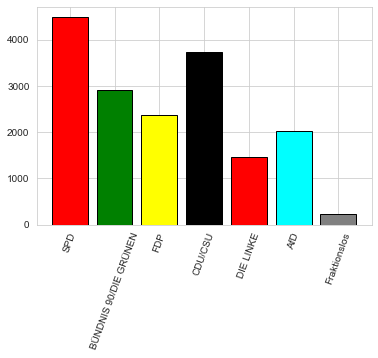

In [34]:
# create a dataset
height = [combined_df_stats['SPD'][0], combined_df_stats['BÜNDNIS 90/DIE GRÜNEN'][0],combined_df_stats['FDP'][0],combined_df_stats['CDU/CSU'][0],combined_df_stats['DIE LINKE'][0],combined_df_stats['AfD'][0],combined_df_stats['Fraktionslos'][0]] # ,combined_df_stats['no tag'][0]
bars = combined_df.columns
x_pos = np.arange(len(bars))

# Create bars
plt.bar(x_pos, height, color=['red', 'green', 'yellow', 'black', 'red', 'cyan', 'grey'], edgecolor='black') # , 'orange'

# Create names on the x-axis
plt.xticks(x_pos, bars, rotation=70)

# Show graph
plt.savefig("barplot.png", transparent=True)
plt.show()

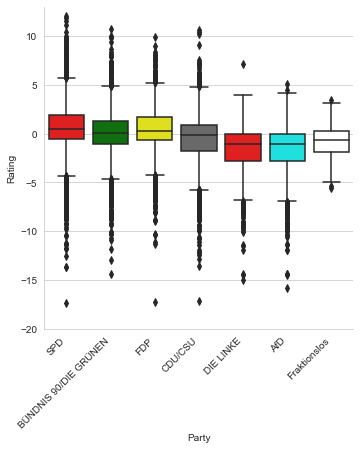

In [42]:
palette = ['red', 'green', 'yellow', 'dimgrey', 'red', 'cyan', 'w']

g = sb.catplot(data=combined_df, kind="box", palette= palette)
g = g.set_axis_labels("Party","Rating").set(ylim=(-20,13))
plt.xticks(rotation=45, ha='right')
plt.show()